Please refer to [Neural Tangents](https://github.com/google/neural-tangents) for dependencies.  
You may need [JAX with GPU Support](https://jax.readthedocs.io/en/latest/installation.html#install-nvidia-gpu).

In [1]:
from jax import random
from neural_tangents import stax
import jax.numpy as jnp
import neural_tangents as nt
import numpy as np

from matplotlib import pyplot as plt

from sklearn.datasets import make_moons

2024-10-02 07:22:17.734953: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-02 07:22:17.752823: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-02 07:22:17.758316: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-02 07:22:18.532966: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


2024-10-02 07:22:20.474563: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.6.20). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


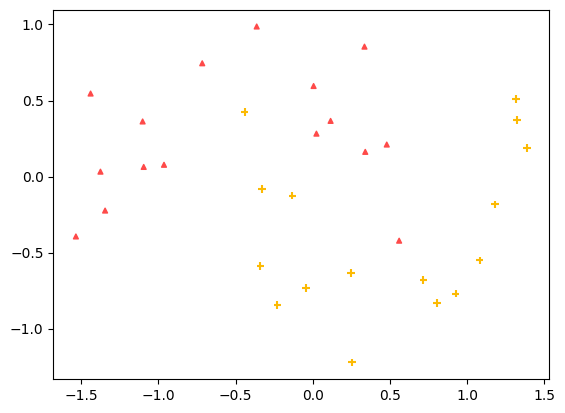

In [2]:
#########################################
# Network definition

hidden_dim = 2048
in_dim = 2

init_fn, apply_fn, kernel_fn = stax.serial(
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(hidden_dim, W_std=2.0, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    # stax.Dense(hidden_dim, W_std=1.5, b_std=0.05), stax.Erf(),# stax.Erf(),
    stax.Dense(1)
)

key = random.PRNGKey(1)
# x = random.normal(key, (10, 1))

#########################################
# Data generation

X_min = -2.25
X_max = 2.25
Y_min = -2.25
Y_max = 2.25
N_val = 64
N_tra = 32

X, y = make_moons(n_samples = N_tra, noise = 0.2, random_state = 330)
X = X + np.array([-0.5, -0.25])
val_x = np.meshgrid(np.linspace(X_min, X_max, num = N_val), np.linspace(Y_min, Y_max, num = N_val))
val_x = np.stack(val_x, axis = -1).reshape(N_val ** 2, 2)

x_tr = jnp.array(X)
x_va = jnp.array(val_x)
y_tr = jnp.array(y)[:, None]
# y_va = jnp.array(dataloaders.get_Y(nvx))[:, None]

plt.scatter(x_tr[:, 0], x_tr[:, 1], s = 12, color = "#fe4a49", alpha = (y_tr == 0), marker = '^')
plt.scatter(x_tr[:, 0], x_tr[:, 1], s = 30, color = "#fcba04", alpha = (y_tr == 1), marker = '+')
plt.show()

In [3]:
print(y_tr)

[[0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [0]
 [1]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]]


In [4]:
################### Direct computation of Linearized dynamics on BCE #####################

from jax.nn import log_sigmoid

k_tr_tr = kernel_fn(x_tr, x_tr, 'ntk')
lr = 1e-2
momentum = 0.9

# predict_fn = nt.predict.gradient_descent_mse_ensemble(kernel_fn, x_tr, y_tr, diag_reg = 5e-1)
loss_fn = lambda fx, y_hat: -jnp.mean(y_hat * log_sigmoid(fx) + (1 - y_hat) * log_sigmoid(-fx))
predict_fn = nt.predict.gradient_descent(
    loss_fn, k_tr_tr, y_tr, lr, momentum
)
# y_val_nngp = predict_fn(x_test = x_va, get = 'nngp')

# y_val_ntk, y_val_ntk_cov = predict_fn(x_test = x_va, get = 'ntk', compute_cov = True)
# # y_val_ntk = predict_fn(x_test = x_va, get = 'nngp', compute_cov = True)

# y = apply_fn(params, x_va)
# y_var = kernel_fn(x_va, x_va, 'nngp')

# # print(x_va)
# # print(y_val_ntk)

# ntk_mean = jnp.reshape(y_val_ntk, (-1,))
# ntk_std = jnp.sqrt(jnp.diag(y_val_ntk_cov))

# cov_scale = 2
# y_lower = ntk_mean - ntk_std * cov_scale
# y_upper = ntk_mean + ntk_std * cov_scale

In [5]:
Ozz = jnp.diag(kernel_fn(x_va, x_va, 'ntk'))
Oxx = jnp.diag(kernel_fn(x_tr, x_tr, 'ntk'))
Ozx = kernel_fn(x_va, x_tr, 'ntk')

In [6]:
from tqdm.notebook import tqdm

t = 6e3
n_samples = 20

y_vals = []
for i in tqdm(range(n_samples)):
    key, net_key = random.split(key)
    _, params = init_fn(key, input_shape=x_tr.shape)
    y_tr_init = apply_fn(params, x_tr)
    y_va_init = apply_fn(params, x_va)
    # help(predict_fn)
    _, y_val_ntk = predict_fn(t, y_tr_init, y_va_init, Ozx)
    y_vals.append(y_val_ntk.reshape(N_val, N_val))

y_vals = np.stack(y_vals)
ntk_std = y_vals.std(0)
print(ntk_std.shape)
# plt.imshow(y_val_ntk.reshape(N_val, N_val))

  0%|          | 0/20 [00:00<?, ?it/s]

(64, 64)


In [7]:
##################### Upper bound by Gronwall Inequality ######################

addition_term = jnp.min(Oxx[None, :] - 2 * Ozx, axis = 1)
UB = Ozz + addition_term

# UB = 0.2 * jnp.exp(2 * jnp.sqrt(UB) - 1)
UB = 0.6 * jnp.sqrt(UB + 1e-2)

mean_term = jnp.mean(Oxx[None, :] - 2 * Ozx, axis = 1)
UB_mean = Ozz + mean_term

In [8]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def create_custom_colormap(color1, color2):
    """
    Create a custom colormap from two input colors.
    
    Parameters:
    color1 (str): The starting color of the colormap.
    color2 (str): The ending color of the colormap.
    
    Returns:
    matplotlib.colors.LinearSegmentedColormap: A custom colormap.
    """
    # Create a list of colors for the colormap
    colors = [color1, color2]
    
    # Create the colormap
    cmap = mcolors.LinearSegmentedColormap.from_list("custom_cmap", colors)
    
    return cmap

<Figure size 210x150 with 0 Axes>

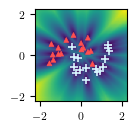

In [20]:
from matplotlib.ticker import FixedLocator, FuncFormatter
############################### VISUALIZATION #################################
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()
plt.figure(figsize = (1.2, 1.2))

im_cmap = create_custom_colormap('#ffffff', '#0496ff')

plt.scatter(x_tr[:, 0], x_tr[:, 1], s = 12, color = "#ff4f4f", linewidths = 0.5, alpha = (y_tr == 0), marker = '^')
plt.scatter(x_tr[:, 0], x_tr[:, 1], s = 30, color = "#d6f5ff", linewidths = 1.2, alpha = (y_tr == 1), marker = '+')

# ax2.scatter(x_tr[:, 0], x_tr[:, 1], s = 4, color = "#ff4f4f", alpha = (y_tr == 0), marker = '^')
# ax2.scatter(x_tr[:, 0], x_tr[:, 1], s = 15, color = "#d6f5ff", alpha = (y_tr == 1), marker = '+')
# plt.imshow(y_vals[2].reshape(N_val, N_val), origin = 'lower', extent = (X_min, X_max, Y_min, Y_max), interpolation = 'lanczos')
# plt.imshow(ntk_std, origin = 'lower', extent = (X_min, X_max, Y_min, Y_max), interpolation = 'lanczos')
plt.imshow((UB.reshape(N_val, N_val)), origin = 'lower', extent = (X_min, X_max, X_min, X_max))
# plt.colorbar()

# ax1.set_yticklabels(['?', '-2', '0', '2'], va='bottom')
# ax2.set_yticklabels(['?', '-2', '0', '2'], va='top')

# plt.legend()
# plt.savefig("test.png", dpi=300)
# plt.savefig("toy-classification-GTBCE.pdf", format="pdf", bbox_inches = 'tight')
plt.savefig("toy-classification-UB.pdf", format="pdf", bbox_inches = 'tight')
# plt.show()

/tmp/ipykernel_3817141/1125305884.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_yticklabels(['?', '-2', '0', '2'], va='top')


<Figure size 210x150 with 0 Axes>

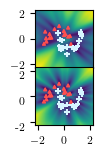

In [9]:
from matplotlib.ticker import FixedLocator, FuncFormatter
############################### VISUALIZATION #################################
plt.style.use('./aaai25.mplstyle')
plt.tight_layout()
# plt.figure(figsize = (2, 2))

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

# Remove top and bottom spines from top and bottom subplots respectively
# ax1.spines['bottom'].set_visible(False)
# ax2.spines['top'].set_visible(False)

# Adjust the positions of the subplots
fig.subplots_adjust(hspace=0)

# Get the current positions
pos1 = ax1.get_position()
pos2 = ax2.get_position()

# ax1.set_xticks([])

# Set new positions
ax1.set_position([pos1.x0, pos1.y0, pos1.width, pos1.height * 1.005])
ax2.set_position([pos2.x0, pos2.y0, pos2.width, pos2.height * 1.005])

im_cmap = create_custom_colormap('#ffffff', '#0496ff')

ax1.scatter(x_tr[:, 0], x_tr[:, 1], s = 4, color = "#ff4f4f", alpha = (y_tr == 0), marker = '^')
ax1.scatter(x_tr[:, 0], x_tr[:, 1], s = 15, color = "#d6f5ff", alpha = (y_tr == 1), marker = '+')

ax2.scatter(x_tr[:, 0], x_tr[:, 1], s = 4, color = "#ff4f4f", alpha = (y_tr == 0), marker = '^')
ax2.scatter(x_tr[:, 0], x_tr[:, 1], s = 15, color = "#d6f5ff", alpha = (y_tr == 1), marker = '+')
# plt.imshow(y_vals[2].reshape(N_val, N_val), origin = 'lower', extent = (X_min, X_max, Y_min, Y_max), interpolation = 'lanczos')
ax1.imshow(ntk_std, origin = 'lower', extent = (X_min, X_max, Y_min, Y_max), interpolation = 'lanczos')
ax2.imshow((UB.reshape(N_val, N_val)), origin = 'lower', extent = (X_min, X_max, X_min, X_max))
# plt.colorbar()

# ax1.set_yticklabels(['?', '-2', '0', '2'], va='bottom')
ax2.set_yticklabels(['?', '-2', '0', '2'], va='top')

# plt.legend()
# plt.savefig("test.png", dpi=300)
plt.savefig("toy-classification-both.pdf", format="pdf", bbox_inches = 'tight')
# plt.show()